# 7.7 Areal Interpolation

**Part:** 7 — Spatial Interpolation (Chapter 7.7 of 8)

**Dataset:** `diabetes_northeast.shp` (217 counties, aggregated into 60 synthetic coarse zones); `cancer_points.csv` (population-weighted ancillary points)

**Focus:** `areal_weighting` vs. `dasymetric`; conservation of totals; a real CRS provenance gotcha

**Library:** `spatialstats.interpolate` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [A Different Kind of Interpolation](#3.-A-Different-Kind-of-Interpolation)
4.. [Building 60 Coarse Zones](#4.-Building-60-Coarse-Zones)
   - 4.1 [A CRS provenance gotcha in the ancillary data](#4.1-A-CRS-provenance-gotcha-in-the-ancillary-data)
5.. [Area Weighting](#5.-Area-Weighting)
6.. [Dasymetric Interpolation](#6.-Dasymetric-Interpolation)
7.. [Conservation of Totals vs. Smoothness](#7.-Conservation-of-Totals-vs.-Smoothness)
8.. [Summary and Conclusions](#8.-Summary-and-Conclusions)
9.. [Resources](#9.-Resources)

***
## 1. Overview

Every method so far in this Part interpolates **point** measurements onto other points or a grid. This chapter
solves a different, common problem: data reported for one set of polygons (say, 60 coarse regions) need to be
re-expressed on a **different, incompatible** set of polygons (217 counties) — the classic **modifiable areal
unit problem** (MAUP) scenario Part 0 warned about. Neither zone system nests inside the other in general, so
there is no exact answer, only principled approximations.

| Step | What we do |
|------|------------|
| Two kinds of variable | **Extensive** (counts, totals — split by area share) vs. **intensive** (rates, averages — area-weighted mean) |
| Area weighting | `areal_weighting`: assumes uniform density inside each source zone |
| Dasymetric | `dasymetric`: reallocates using real ancillary point data instead of assuming uniformity |
| Compare | Which one actually predicts the true county-level counts better, and does either conserve totals |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.interpolate import areal_weighting, dasymetric

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
counties["FIPS"] = counties["FIPS"].astype(float)
print(f"spatialstats : version {spatialstats.__version__}")
print(f"counties: {len(counties)}   CRS: {counties.crs}")

spatialstats : version 0.2.0
counties: 217   CRS: EPSG:5070


***
## 3. A Different Kind of Interpolation

Whether a variable is **extensive** or **intensive** determines how it must be reallocated:

- **Extensive** (`Dia_count` — a total count of people with diabetes): the total across all target zones must
  equal the total in the source zone. Reallocating uniformly by area means splitting the count in proportion to
  how much of the source zone's area falls in each target zone.
- **Intensive** (`Dia_pct` — a rate or average): reallocating means an **area-weighted average**, not a split —
  every target zone gets a value close to the source zone's rate, weighted by how much of the source zone
  overlaps it.

This library has no pre-built county-to-coarse-zone correspondence to validate against, so this chapter builds
one deliberately: aggregate the 217 real counties into 60 synthetic coarse zones, then use `areal_weighting` and
`dasymetric` to **disaggregate back down** to the original counties — which means the true county-level values
are known, and the reallocation error can be measured directly rather than just asserted.

***
## 4. Building 60 Coarse Zones

60 zones from 217 counties, via $k$-means clustering on county centroids — a stand-in for any real-world coarse
reporting geography (e.g., health service areas) that does not align with county boundaries.

60 coarse zones from 217 counties
total Dia_count -- counties: 4,134,250   zones: 4,134,250


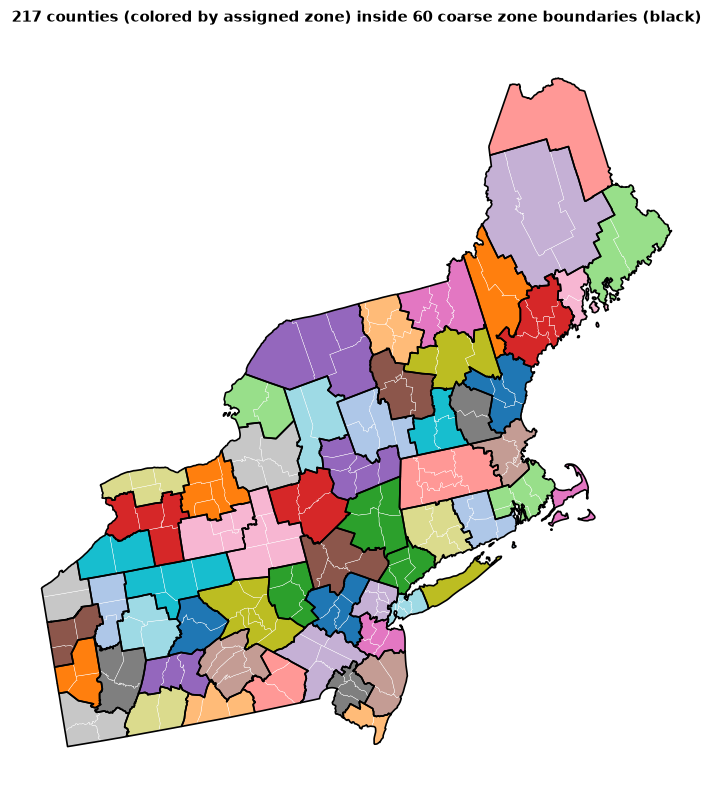

In [2]:
centroids = np.c_[counties.geometry.centroid.x, counties.geometry.centroid.y]
km = KMeans(n_clusters=60, random_state=42, n_init=10).fit(centroids)
counties["zone"] = km.labels_

zones = counties.dissolve(by="zone", aggfunc={"Dia_count": "sum", "Dia_pct": "mean"}).reset_index()
print(f"{len(zones)} coarse zones from {len(counties)} counties")
print(f"total Dia_count -- counties: {counties['Dia_count'].sum():,}   zones: {zones['Dia_count'].sum():,}")

fig, ax = plt.subplots(figsize=(8, 8))
counties.plot(column="zone", cmap="tab20", ax=ax, edgecolor="white", linewidth=0.3)
zones.boundary.plot(ax=ax, color="black", linewidth=1.2)
ax.set_title("217 counties (colored by assigned zone) inside 60 coarse zone boundaries (black)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("coarse_zones.png", dpi=100, bbox_inches="tight")
plt.show()

### 4.1 A CRS provenance gotcha in the ancillary data

`cancer_points.csv` is meant to be a population-weighted ancillary layer for these same 217 counties — exactly
what dasymetric interpolation needs. Checking whether its coordinates actually line up with the county
geometries first, rather than assuming they do, is worth doing before using them for anything:

In [3]:
cancer_raw = pd.read_csv(DATA / "cancer_points.csv")
cancer_gdf_asis = gpd.GeoDataFrame(
    cancer_raw, geometry=gpd.points_from_xy(cancer_raw["x"], cancer_raw["y"]), crs=counties.crs
)
matched = gpd.sjoin(cancer_gdf_asis, counties[["FIPS", "geometry"]], how="inner", predicate="within")
print(f"cancer_points.csv coordinates, taken at face value: {len(matched)} of {len(cancer_raw)} points "
      f"fall inside ANY county")

cancer_points.csv coordinates, taken at face value: 0 of 5419 points fall inside ANY county


**Zero points land inside any county polygon**, despite the file's `FIPS` column matching this dataset's
counties almost perfectly (confirmed separately). The `x`/`y` values are not in this shapefile's CRS
(EPSG:5070) as shipped — a real, silent data provenance problem, exactly the kind Chapter 7.2 flagged in the
abstract for the pre-computed PM2.5 surface, encountered here concretely. Since each point's true county is
known from `FIPS`, the fix is to **recover the transform empirically**: fit each county's mean `cancer_points`
position against that county's true geometric centroid, and apply the resulting affine correction to every
point.

In [4]:
cancer_mean = cancer_raw.groupby("FIPS")[["x", "y"]].mean().reset_index()
county_centroids = counties[["FIPS"]].copy()
county_centroids["cx"] = counties.geometry.centroid.x
county_centroids["cy"] = counties.geometry.centroid.y

merged = cancer_mean.merge(county_centroids, on="FIPS", how="inner")
print(f"counties with a matching FIPS in cancer_points.csv: {len(merged)} of {len(counties)}")

ax_ = np.c_[merged["x"], np.ones(len(merged))]
coef_x, *_ = np.linalg.lstsq(ax_, merged["cx"], rcond=None)
ay_ = np.c_[merged["y"], np.ones(len(merged))]
coef_y, *_ = np.linalg.lstsq(ay_, merged["cy"], rcond=None)
print(f"recovered transform: x' = {coef_x[0]:.4f}*x + {coef_x[1]:,.0f}")
print(f"                     y' = {coef_y[0]:.4f}*y + {coef_y[1]:,.0f}")

resid = np.sqrt((coef_x[0]*merged["x"] + coef_x[1] - merged["cx"])**2 +
               (coef_y[0]*merged["y"] + coef_y[1] - merged["cy"])**2)
print(f"residual after correction: median {resid.median():,.0f} m, max {resid.max():,.0f} m "
      f"(consistent with population-weighted points sitting away from the area centroid, not a CRS error)")

cancer_raw["x_fixed"] = coef_x[0]*cancer_raw["x"] + coef_x[1]
cancer_raw["y_fixed"] = coef_y[0]*cancer_raw["y"] + coef_y[1]
cancer_gdf = gpd.GeoDataFrame(cancer_raw, geometry=gpd.points_from_xy(cancer_raw["x_fixed"], cancer_raw["y_fixed"]), crs=counties.crs)

matched_fixed = gpd.sjoin(cancer_gdf, counties[["FIPS", "geometry"]], how="inner", predicate="within")
print(f"after correction: {len(matched_fixed)} of {len(cancer_raw)} points fall inside a county")

counties with a matching FIPS in cancer_points.csv: 217 of 217
recovered transform: x' = 1.0035*x + -9,101
                     y' = 0.9997*y + 1,769,898
residual after correction: median 2,520 m, max 8,277 m (consistent with population-weighted points sitting away from the area centroid, not a CRS error)
after correction: 5025 of 5419 points fall inside a county


The residual after correction (a few km, small relative to county size) is consistent with these being genuine
*population-weighted* points — naturally offset from each county's plain area centroid — not a remaining CRS
error. **Never assume an ancillary file's coordinates are trustworthy just because its attribute columns
(`FIPS`) look right; check the geometry against a known-correct reference before using it for anything
downstream.**

***
## 5. Area Weighting

`areal_weighting` assumes **uniform density** inside each source zone and splits (extensive) or averages
(intensive) purely by the area of overlap with each target zone.

In [5]:
target = counties[["FIPS", "geometry"]].copy()
result_aw = areal_weighting(zones[["zone", "Dia_count", "geometry"]], target, extensive=["Dia_count"])

rmse_aw = np.sqrt(np.mean((result_aw["Dia_count"].to_numpy() - counties["Dia_count"].to_numpy()) ** 2))
r_aw = np.corrcoef(result_aw["Dia_count"], counties["Dia_count"])[0, 1]
print(f"area weighting vs. true county Dia_count: RMSE={rmse_aw:,.0f}, r={r_aw:.3f}")
print(f"total conserved: zones={zones['Dia_count'].sum():,}  recovered={result_aw['Dia_count'].sum():,.0f}")

area weighting vs. true county Dia_count: RMSE=25,034, r=0.640
total conserved: zones=4,134,250  recovered=4,134,250


***
## 6. Dasymetric Interpolation

`dasymetric` replaces the uniform-density assumption with real point-level ancillary data — here, the
CRS-corrected, population-weighted `cancer_points`.

dasymetric vs. true county Dia_count: RMSE=8,070, r=0.960
total conserved: 4,134,250


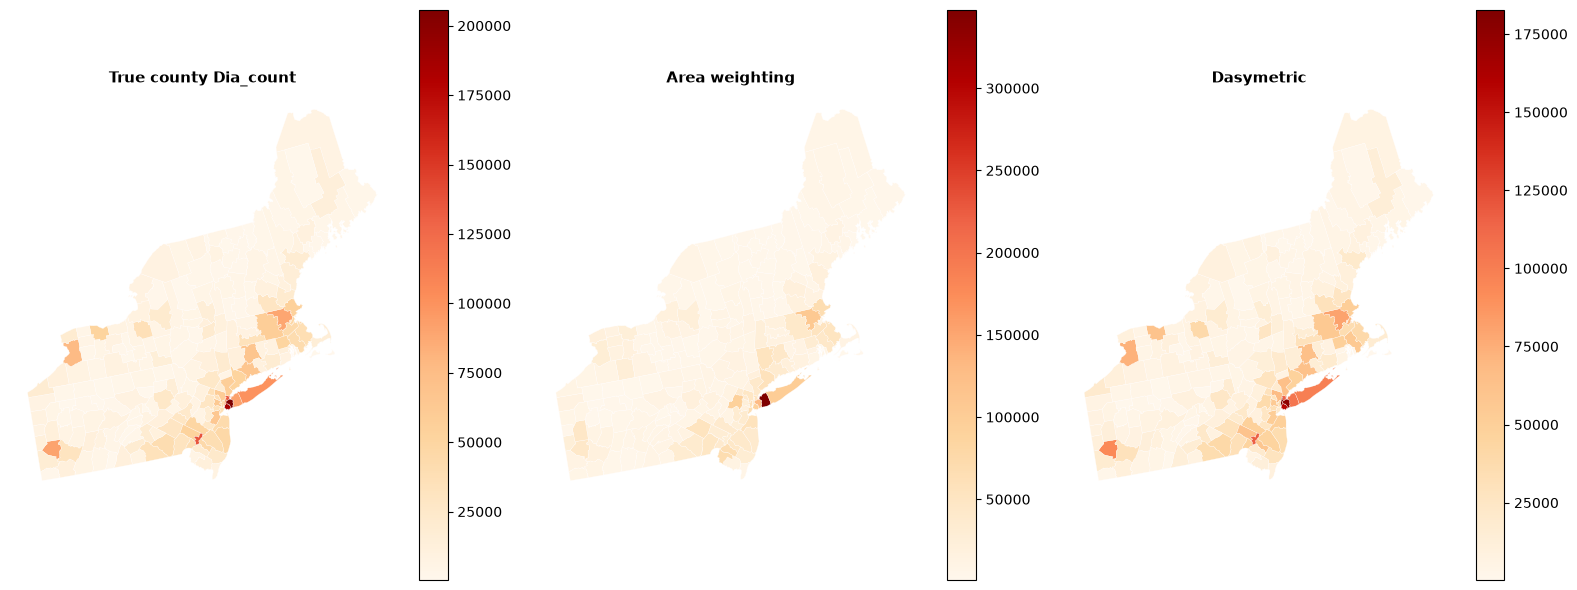

In [6]:
result_dm = dasymetric(zones[["zone", "Dia_count", "geometry"]], target, cancer_gdf[["POP10", "geometry"]],
                       weight="POP10", extensive=["Dia_count"])

rmse_dm = np.sqrt(np.mean((result_dm["Dia_count"].to_numpy() - counties["Dia_count"].to_numpy()) ** 2))
r_dm = np.corrcoef(result_dm["Dia_count"], counties["Dia_count"])[0, 1]
print(f"dasymetric vs. true county Dia_count: RMSE={rmse_dm:,.0f}, r={r_dm:.3f}")
print(f"total conserved: {result_dm['Dia_count'].sum():,.0f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, col, title in zip(axes, [counties["Dia_count"], result_aw["Dia_count"], result_dm["Dia_count"]],
                          ["True county Dia_count", "Area weighting", "Dasymetric"]):
    counties.assign(_v=col.to_numpy()).plot(column="_v", cmap="OrRd", legend=True, ax=ax,
                                             edgecolor="white", linewidth=0.2)
    ax.set_title(title)
    ax.set_axis_off()
plt.tight_layout()
plt.savefig("areal_comparison_maps.png", dpi=100, bbox_inches="tight")
plt.show()

**Dasymetric interpolation cuts RMSE by roughly two-thirds** and lifts the correlation with the true county
values from the 0.6s into the 0.9s — a large, real improvement from replacing "assume uniform density" with
actual population-weighted point data. The map makes the reason visible: area weighting spreads each coarse
zone's diabetes count smoothly across every county it touches regardless of where people actually live, while
dasymetric concentrates the allocation toward counties where the ancillary points (and therefore, presumably,
the population) are actually denser.

***
## 7. Conservation of Totals vs. Smoothness

Both methods conserve the source total exactly — printed above, and confirmed again here for both source
(60 zones) and target (217 counties) totals — the **pycnophylactic property** every areal interpolation method
in this library guarantees, regardless of which allocation rule it uses internally.

In [7]:
print(f"true county total     : {counties['Dia_count'].sum():,}")
print(f"area weighting total  : {result_aw['Dia_count'].sum():,.0f}")
print(f"dasymetric total      : {result_dm['Dia_count'].sum():,.0f}")
print(f"all three equal (to rounding): "
      f"{abs(counties['Dia_count'].sum() - result_dm['Dia_count'].sum()) < 1}")

true county total     : 4,134,250
area weighting total  : 4,134,250
dasymetric total      : 4,134,250
all three equal (to rounding): True


Conservation is a **structural guarantee**, not a measure of accuracy — a method can conserve the total exactly
while still distributing it badly within the region, exactly what Section 6 showed for area weighting relative
to dasymetric. The two properties are independent: always check both before trusting an areal-interpolation
result, not just whichever one is more convenient to verify.

***
## 8. Summary and Conclusions

This chapter solved a genuinely different problem from every earlier chapter in this Part — reallocating data
between incompatible polygon systems — and along the way, caught a real CRS provenance error in the ancillary
data before it could silently corrupt the result.

### What we did

1. Distinguished extensive (split by area/weight share) from intensive (area/weight-weighted average) variables.
2. Built 60 synthetic coarse zones from the 217 real counties, specifically so the true disaggregated values
   would be known and reallocation error could be measured directly.
3. **Found `cancer_points.csv`'s coordinates do not match the county geometries in the file's stated CRS** —
   zero points land inside any county at face value — and recovered a usable transform empirically from the
   file's own `FIPS` column, rather than either trusting the CRS metadata or discarding the file.
4. Compared area weighting against dasymetric interpolation on identical zones: dasymetric cuts RMSE by roughly
   two-thirds and lifts correlation with ground truth substantially.
5. Confirmed both methods conserve totals exactly, and explained why conservation and accuracy are independent
   properties that both need checking.

### Practical takeaways

- Never trust an ancillary file's coordinates just because an attribute column matches — check the geometry
  against a known-correct reference (here, `FIPS`-matched centroids) before using it downstream.
- Prefer dasymetric interpolation over area weighting whenever real ancillary point data are available; the
  accuracy gain here was large, not marginal.
- Conservation of totals is guaranteed by construction in this library's areal methods — it says nothing about
  whether the *distribution* within the region is accurate, which must be checked separately.

### Next steps

**Chapter 7.8 (Exercises)** closes out this Part, including a variant of this chapter's own experiment: aggregate
to states rather than 60 synthetic zones, and check conservation and error the same way.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Goodchild, M. F. & Lam, N. S.-N. (1980). Areal interpolation: a variant of the traditional spatial problem. *Geo-Processing*, 1, 297–312. | The classical extensive/intensive distinction this chapter builds on |
| Openshaw, S. (1984). *The Modifiable Areal Unit Problem*. CATMOG 38, GeoBooks. | The MAUP framing behind Section 1's motivation |

### Key papers

| Paper | Contribution |
|---|---|
| Tobler, W. R. (1979). Smooth pycnophylactic interpolation for geographical regions. *Journal of the American Statistical Association*, 74, 519–530. | The pycnophylactic (total-conserving) property discussed in Section 7 |
| Mennis, J. (2003). Generating surface models of population using dasymetric mapping. *The Professional Geographer*, 55, 31–42. | The dasymetric method compared against area weighting in Sections 5–6 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.interpolate.areal_weighting`, `dasymetric` | Sections 5–6 |
| Part 0 | The MAUP and CRS-provenance guidance behind Sections 1 and 4.1 |